

# Text Analytics Storms ML
### OPIM 5512 — Applied Data Science · Module5

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-notebooks/blob/main/Module5/Text_Analytics_Storms_ML.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

#Text Analytics, ML models and xAI with Storm Data
-----------------
**Dr. Dave Wanik - Operations and Information Management - University of Connecticut**

*Thanks to my former student Vineela Datla for sharing data and ideas for this week's class!*

In this project, the goal is to be able to classify text. The data is from the NOAA website that has descriptive data about the storm events.
https://www1.ncdc.noaa.gov/pub/data/swdi/stormevents/csvfiles/

This example can generalize to ANY text classification problem and EDA you want to solve - so long as your data is stored in a .csv, you can use most of this code directly with only light editing.

In [ ]:
# import modules
import numpy as np
import pandas as pd

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# need to add nltk imports up here
# link: https://www.nltk.org/
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

We read in the data and see this has a traditional database output, with some limited numeric columns. The best data is all the way to the right (comment fields!)

In the old days, I would've deleted these things since I had no use for them - but now, with all of the open-source software available, you can really bring that data to life and 1) not only explore it but 2) build models with it! Let's get to work.

In [ ]:
# https://drive.google.com/file/d/1-BoSFgp9oULcOcGwdV0IVi9_2kDRMX8V/view?usp=sharing
!gdown 1-BoSFgp9oULcOcGwdV0IVi9_2kDRMX8V

Downloading...
From: https://drive.google.com/uc?id=1-BoSFgp9oULcOcGwdV0IVi9_2kDRMX8V
To: /content/StormEvents_2019.csv
100% 41.3M/41.3M [00:00<00:00, 112MB/s] 


In [ ]:
storm_df = pd.read_csv('StormEvents_2019.csv')
storm_df.shape

(61324, 8)

Let's look at a sample text examples. There is a detailed column (EPISODE_NARRATIVE) and a more concise column (EVENT_NARRATIVE).

In [ ]:
# there's a more detailed column called "EPISODE_NARRATIVE"
print(storm_df['EPISODE_NARRATIVE'][0])
print(storm_df['EPISODE_NARRATIVE'][1])
print(storm_df['EPISODE_NARRATIVE'][2])

Thunderstorms developed along a cold front as it moved through South Central Texas. Some of these storms produced large hail, damaging wind gusts, and heavy rain that led to flash flooding.
An area of low pressure over southern Manitoba the morning of the 15th moved to near southern Hudson Bay by the morning of the 16th. A cold front associated with this low moved across the Northland during the afternoon and evening hours of the 15th. A warm front had moved through on the previous day brought a warm and unstable airmass in its wake. The cold front then worked with this airmass to create severe storms from northeast Minnesota into northwest Wisconsin and western Lake Superior. Damaging winds accounted for most of the reports with these storms, although there was some marginally severe hail as well. Most of the damage was to trees, but some property damage to pontoon boats and a home also occurred.
Thunderstorms erupted across the DFW Metroplex as a strong upper level system and a cold 

In [ ]:
# first observations from storm_df['EVENT_NARRATIVE']
print(storm_df['EVENT_NARRATIVE'][0])
print(storm_df['EVENT_NARRATIVE'][1])
print(storm_df['EVENT_NARRATIVE'][2])

Thunderstorms produced heavy rain that led to flash flooding. Multiple low water crossings were closed in northwestern Bexar County.
A 14-inch tree fell due to the winds and damaged a garage, vehicle and a light pole.
A trained spotter measured a wind gust of 67 MPH approximately one mile north of the city of Edgewood, TX.


As we are trying to classify event type based on the narrative, lets get rid of the rows where the data narrative is not available

In [ ]:
# Checking for null values in event narrative column
storm_df.info()

# the data is MOSTLY good but has some nulls, so we drop it.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61324 entries, 0 to 61323
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EVENT_ID           61324 non-null  int64 
 1   STATE              61324 non-null  object
 2   STATE_FIPS         61324 non-null  int64 
 3   YEAR               61324 non-null  int64 
 4   MONTH_NAME         61324 non-null  object
 5   EVENT_TYPE         61324 non-null  object
 6   EPISODE_NARRATIVE  61324 non-null  object
 7   EVENT_NARRATIVE    48324 non-null  object
dtypes: int64(3), object(5)
memory usage: 3.7+ MB


In [ ]:
# Dropping rows where event narrative is empty...
event_df = storm_df.dropna(subset=['EVENT_NARRATIVE'])
print(event_df.shape) # now we have 48K rows
event_df.head()

(48324, 8)


,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,824116,TEXAS,48,2019,May,Flash Flood,Thunderstorms developed along a cold front as ...,Thunderstorms produced heavy rain that led to ...
1,843354,MINNESOTA,27,2019,July,Thunderstorm Wind,An area of low pressure over southern Manitoba...,A 14-inch tree fell due to the winds and damag...
2,861581,TEXAS,48,2019,October,Thunderstorm Wind,Thunderstorms erupted across the DFW Metroplex...,A trained spotter measured a wind gust of 67 M...
3,861584,TEXAS,48,2019,October,Thunderstorm Wind,Thunderstorms erupted across the DFW Metroplex...,The local police department reported a wind gu...
4,861582,TEXAS,48,2019,October,Thunderstorm Wind,Thunderstorms erupted across the DFW Metroplex...,A wind gust of 75 MPH was measured by the Auto...


We can make a nice barplot of the different storm types.

/tmp/ipython-input-310206756.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)


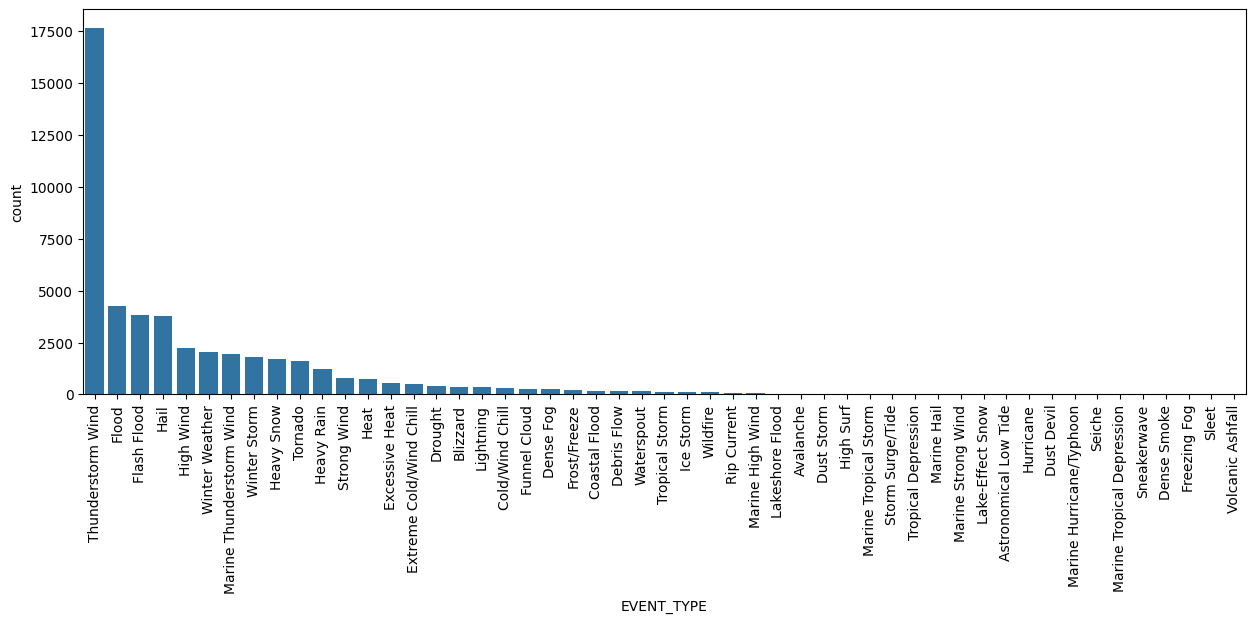

In [ ]:
# to sort by frequency...
# link: https://stackoverflow.com/questions/46623583/seaborn-countplot-order-categories-by-count

plt.figure(figsize=(15,5))
ax = sns.countplot(x="EVENT_TYPE", data=event_df,
                   order = event_df['EVENT_TYPE'].value_counts().index)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
plt.show()

**Figure 1:** frequncy of records by storm type/bar plot.

In [ ]:
# subset those storms that have at least 300 observations
final_df = event_df[event_df.groupby("EVENT_TYPE")["EVENT_ID"].transform('count')>300]
final_df.groupby("EVENT_TYPE")["EVENT_ID"].count()

,EVENT_ID
EVENT_TYPE,
Blizzard,345
Cold/Wind Chill,308
Drought,421
Excessive Heat,553
Extreme Cold/Wind Chill,526
Flash Flood,3851
Flood,4253
Hail,3783
Heat,733


/tmp/ipython-input-675843082.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)


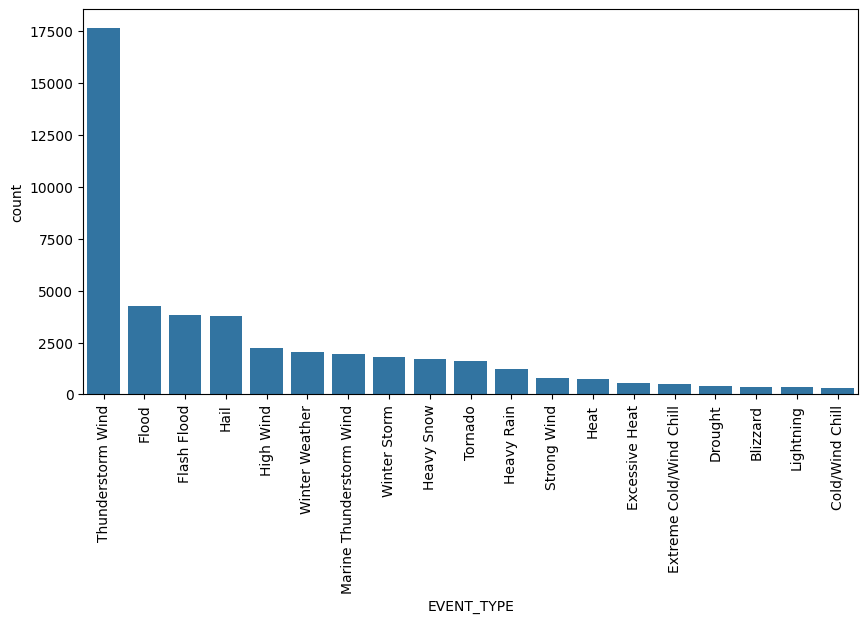

In [ ]:
# show a plot of the different categories (count of obserations)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
ax = sns.countplot(x="EVENT_TYPE", data=final_df,
                   order = final_df['EVENT_TYPE'].value_counts().index)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
plt.show()

**Figure 2:** frequncy of records by storm type/bar plot (must have 300 records.)

Remember, we've made three different versions of the data now:
* storm_df (original data)
* event_df (has only complete rows for text data)
* final_df (contains storms with as least 300 counts)

# Exploring the text data
Let's compare hail storms and flash floods and see what's going on.

# Subset Hail data
First things first - let's take a peak at just the hail storms.

In [ ]:
hail_df = final_df[final_df['EVENT_TYPE']=='Hail'].copy()
hail_df.info() # looks like there are 3783 hail storms

<class 'pandas.core.frame.DataFrame'>
Index: 3783 entries, 6 to 61237
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EVENT_ID           3783 non-null   int64 
 1   STATE              3783 non-null   object
 2   STATE_FIPS         3783 non-null   int64 
 3   YEAR               3783 non-null   int64 
 4   MONTH_NAME         3783 non-null   object
 5   EVENT_TYPE         3783 non-null   object
 6   EPISODE_NARRATIVE  3783 non-null   object
 7   EVENT_NARRATIVE    3783 non-null   object
dtypes: int64(3), object(5)
memory usage: 266.0+ KB


# Traditional EDA on the Hail Data
How many injuries and deaths were there? What was the damage to property and crops? The injury and death data is int64 (numeric), but we will need to wrangle the property and crop data (it's stored as a string, because there a K and M at the end of the number!)

# Dig into the Event Narrative
We can build models for classification based on Episode Narrative or Event Narrative! Let's explore!!!

In [ ]:
# reset the index just so it looks nice
hail_df.reset_index(inplace=True)
hail_df.head()

,index,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,6,848333,VERMONT,50,2019,September,Hail,A strong mid-level disturbance and cold front ...,Quarter size hail reported at Okemo Ski resort.
1,20,844159,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,Trained spotter reported hail up to the size o...
2,21,844160,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"Public reported, via social media, quarter siz..."
3,31,844158,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,Public reported quarter size hail.
4,42,852318,CONNECTICUT,9,2019,September,Hail,A cold front pushed through southern New Engla...,Dime size hail was reported in Enfield.


In [ ]:
# get rid of the original index column
del hail_df['index']
print(hail_df.shape)
hail_df.head()

(3783, 8)


,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,848333,VERMONT,50,2019,September,Hail,A strong mid-level disturbance and cold front ...,Quarter size hail reported at Okemo Ski resort.
1,844159,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,Trained spotter reported hail up to the size o...
2,844160,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"Public reported, via social media, quarter siz..."
3,844158,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,Public reported quarter size hail.
4,852318,CONNECTICUT,9,2019,September,Hail,A cold front pushed through southern New Engla...,Dime size hail was reported in Enfield.


### Lowercase
There is no difference between the words "HAIL", "Hail" and "hail"...
To make our analysis more meaningful, we make all of these words lowercase.

In [ ]:
# make everything lowercase
hail_df['EVENT_NARRATIVE'] = hail_df['EVENT_NARRATIVE'].str.lower()
hail_df.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,848333,VERMONT,50,2019,September,Hail,A strong mid-level disturbance and cold front ...,quarter size hail reported at okemo ski resort.
1,844159,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,trained spotter reported hail up to the size o...
2,844160,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"public reported, via social media, quarter siz..."
3,844158,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,public reported quarter size hail.
4,852318,CONNECTICUT,9,2019,September,Hail,A cold front pushed through southern New Engla...,dime size hail was reported in enfield.


In [ ]:
# here's an example of what we did
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

quarter size hail reported at okemo ski resort.
trained spotter reported hail up to the size of quarters, along with heavy rain and standing water in their yard.
public reported, via social media, quarter size hail.


### Strip funky characters (!,~-@$% etc)
Funky characters can be a pain - they make words appear to be unique (think of trouble with strings). Let's ditch 'em!

In [ ]:
hail_df['EVENT_NARRATIVE'] = hail_df['EVENT_NARRATIVE'].str.lower()
hail_df['EVENT_NARRATIVE'] = hail_df['EVENT_NARRATIVE'].str.replace(r'[^a-zA-Z ]','', regex=True).str.replace(r' +',' ', regex=True).str.strip()
hail_df.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,848333,VERMONT,50,2019,September,Hail,A strong mid-level disturbance and cold front ...,quarter size hail reported at okemo ski resort
1,844159,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,trained spotter reported hail up to the size o...
2,844160,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,public reported via social media quarter size ...
3,844158,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,public reported quarter size hail
4,852318,CONNECTICUT,9,2019,September,Hail,A cold front pushed through southern New Engla...,dime size hail was reported in enfield


In [ ]:
# let's see what we did, no commas or periods!
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

quarter size hail reported at okemo ski resort
trained spotter reported hail up to the size of quarters along with heavy rain and standing water in their yard
public reported via social media quarter size hail


### Stop words
'Stop words' are simply common words in the English language - they are not special and generally don't convey too much information. So it's best to get rid of them.

In [ ]:
# let's remove some of the stop words (see what happens if you comment this cell out)
# we can do better!
# define some stop words
import nltk
from nltk.corpus import stopwords


nltk.download('stopwords') # this makes sure these are downloaded if you haven't already!
print(stopwords.words('english'))

stop = stopwords.words('english') # see why it's important to turn everything lower case? all of your stopwords are!

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# remove the stop words
# apply these stopwords to the data
# link: https://stackoverflow.com/questions/29523254/python-remove-stop-words-from-pandas-dataframe/43407993

# this looks good!
# ' '. adds a nice space (try adding a 'D' instead of ' ' and see what happens!)
hail_df.head() # note how the stop words have been removed
hail_df["EVENT_NARRATIVE"] = hail_df['EVENT_NARRATIVE'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
hail_df.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,848333,VERMONT,50,2019,September,Hail,A strong mid-level disturbance and cold front ...,quarter size hail reported okemo ski resort
1,844159,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,trained spotter reported hail size quarters al...
2,844160,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,public reported via social media quarter size ...
3,844158,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,public reported quarter size hail
4,852318,CONNECTICUT,9,2019,September,Hail,A cold front pushed through southern New Engla...,dime size hail reported enfield


In [ ]:
# let's see what we did, no commas or periods!
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

quarter size hail reported okemo ski resort
trained spotter reported hail size quarters along heavy rain standing water yard
public reported via social media quarter size hail


# Text EDA on the Hail Data

### Most common words
Word clouds and frequency tables/plots.

In [ ]:
# 1) what are the most common words in the EVENT_NARRATIVE? note that we are doing this before tokenizer
# you can also turn this into a bar plot!
myTable = hail_df['EVENT_NARRATIVE'].str.split(expand=True).stack().value_counts()
myTable[0:20] # too cool!

,count
hail,3611
reported,1955
size,1862
quarter,1037
sized,678
ball,514
report,461
near,425
spotter,416
inch,397


In [ ]:
# and we can make a frequency plot
# we'll group, then convert to pandas DataFrame for easy plotting
x = hail_df['EVENT_NARRATIVE'].str.split(expand=True).stack().value_counts()
x = pd.DataFrame(x)
# reset the index
x.reset_index(inplace=True)
# rename the columns
x.rename(columns={x.columns[0]:'word', x.columns[1]:'frequency'}, inplace=True)
x.head()

,word,frequency
0,hail,3611
1,reported,1955
2,size,1862
3,quarter,1037
4,sized,678


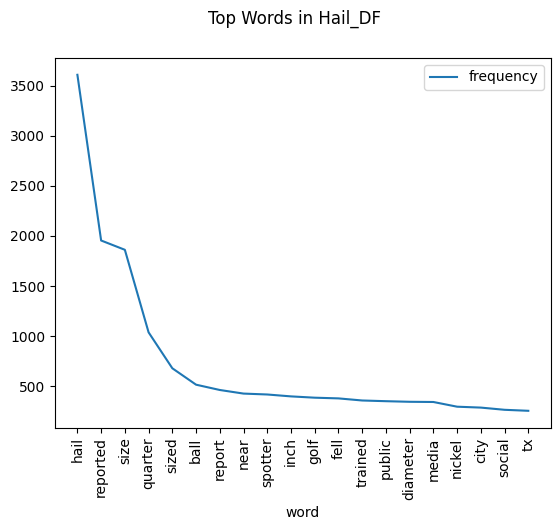

In [ ]:
# Frequency Distribution Plot
# look at first X words

# len(x) just the number of rows

x = x[0:20] # wanna play? change the 20 to 10 or 30 and see what happens...
            # you need to run the previous cell first
x.plot(x='word', y='frequency')
plt.xticks(np.arange(len(x)), x['word'], rotation=90)
plt.suptitle('Top Words in Hail_DF')
plt.show()


**Figure 3:** top words in hail_df.

In [ ]:
# # if we wanted to, we could delete 'hail' so that the model isn't cheating!
# # to do this, we just need to append our stop words...

# # i will keep this commented out for now, but it's possible to do this and repeat the notebook!

# # not shown here, but like this
# # link: https://stackabuse.com/removing-stop-words-from-strings-in-python/#:~:text=Using%20Python's%20NLTK%20Library&text=NLTK%20supports%20stop%20word%20removal,stop%20words%20provided%20by%20NLTK.

# # import
# nltk.download('punkt')
# from nltk.tokenize import word_tokenize

# sw_list = ['hail']
# stop.extend(sw_list)

# text_tokens = word_tokenize(str(hail_df["EVENT_NARRATIVE"]))
# tokens_without_sw = [word for word in text_tokens if not word in stop]

# print(tokens_without_sw) # see, now hail is gone!!!
# # would the model do just as well without hail in the description?

### Word Cloud
Instead of just word frequency, you can get a nice graphic like this! Words that are most common are large. You can read more about customization here:
https://www.datacamp.com/community/tutorials/wordcloud-python

You can be creative here!!!

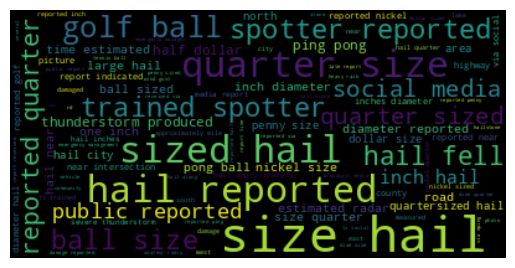

In [ ]:
# https://amueller.github.io/word_cloud/auto_examples/simple.html#sphx-glr-auto-examples-simple-py

from wordcloud import WordCloud

# Generate a word cloud image
wordcloud = WordCloud().generate(' '.join(hail_df['EVENT_NARRATIVE']))

# # Display the generated image:
# # the matplotlib way:
# import matplotlib.pyplot as plt
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")

# lower max_font_size
wordcloud = WordCloud(max_font_size=40).generate(' '.join(hail_df['EVENT_NARRATIVE']))
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

**Figure 4:** a word cloud of top words in hail_df. size is proportional to frequency.

### Tokenizer
The tokenizer takes a given sentence and parses it into a list with individual words separated by a comma. This makes it easy for us to do some feature engineering later on in the notebook.

In [ ]:
# tokenizer
# hello tokenizer! make this a list with individual entries/values
nltk.download('punkt_tab')
hail_df['EVENT_NARRATIVE'] = hail_df.apply(lambda row: nltk.word_tokenize(row['EVENT_NARRATIVE']), axis=1)
hail_df.head()
# could also have created a new column?
# link: https://stackoverflow.com/questions/33098040/how-to-use-word-tokenize-in-data-frame

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,848333,VERMONT,50,2019,September,Hail,A strong mid-level disturbance and cold front ...,"[quarter, size, hail, reported, okemo, ski, re..."
1,844159,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"[trained, spotter, reported, hail, size, quart..."
2,844160,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"[public, reported, via, social, media, quarter..."
3,844158,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"[public, reported, quarter, size, hail]"
4,852318,CONNECTICUT,9,2019,September,Hail,A cold front pushed through southern New Engla...,"[dime, size, hail, reported, enfield]"


In [ ]:
# here's what we did
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

['quarter', 'size', 'hail', 'reported', 'okemo', 'ski', 'resort']
['trained', 'spotter', 'reported', 'hail', 'size', 'quarters', 'along', 'heavy', 'rain', 'standing', 'water', 'yard']
['public', 'reported', 'via', 'social', 'media', 'quarter', 'size', 'hail']


### Summary
So what did we do? We processed our data to make it all lower case, got rid of funky characters, removed stop words and used the 'tokenizer' to start to parse our text data into something useable. Let's dig into some more examples.

# Lexicon Normalization
This is a fancy word that means we want to take the words (lexicon) and get them in some standardized fashion (normalization). Our goal is to simply the information in our model.

### Stemming
From DataCamp: Stemming is a process of linguistic normalization, which reduces words to their word root word or chops off the derivational affixes. For example, connection, connected, connecting word reduce to a common word "connec".

How can we use this? Use these simpler representations of the words to build your model "connec" (0/1) vs. having three different 0/1 variables for 'connection', 'connected', 'connecting' etc. See where we are going with this? It's all about teaching the computer how to exploit this unstructured data!

In [ ]:
# we won't use this today, but sure, it's possible to chop a word down
# this cuts down on dimensionality
# using the example above, three words turn into one "connec"

from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize

# this is the function we will use
ps = PorterStemmer()

filtered_sent = hail_df['EVENT_NARRATIVE'][0]

stemmed_words=[]
for w in filtered_sent:
    stemmed_words.append(ps.stem(w))

print("Filtered Sentence:",filtered_sent)
print("Stemmed Sentence:",stemmed_words)

# in our example, we just got rid of "reported"

Filtered Sentence: ['quarter', 'size', 'hail', 'reported', 'okemo', 'ski', 'resort']
Stemmed Sentence: ['quarter', 'size', 'hail', 'report', 'okemo', 'ski', 'resort']


In [ ]:
# if we wanted to, we could make a new column with just the stemmed words
# link: https://stackoverflow.com/questions/37443138/python-stemming-with-pandas-dataframe
hail_df['Stemmed'] = hail_df['EVENT_NARRATIVE'].apply(lambda x: [ps.stem(y) for y in x]) # Stem every word.

In [ ]:
# check your work!
print(hail_df['EVENT_NARRATIVE'][0]) # reported
print(hail_df['Stemmed'][0]) # report

print(hail_df['EVENT_NARRATIVE'][10]) # note the difference between inches, reported, covered
print(hail_df['Stemmed'][10]) # inch, report, cover

['quarter', 'size', 'hail', 'reported', 'okemo', 'ski', 'resort']
['quarter', 'size', 'hail', 'report', 'okemo', 'ski', 'resort']
['hail', 'inches', 'reported', 'hail', 'covered', 'ground']
['hail', 'inch', 'report', 'hail', 'cover', 'ground']


It doesn't seem like we get crazy different results between Stemming and the raw data in our example.

# Putting it all together (quickly) for Flash Flood
OK so we did a bunch on hail data... let's also look at 'Flash Flood' and create the stemmed words. THEN we will prep our data for modeling and see if we can build a model that can 'read' comments and make a proper classification!

The same logic that we are working through here can apply to sentiment analysis for Twitter or Amazon reviews etc. But notice that right now that all of our data lives nicely curated inside of a pandas dataframe. Later on in your analytics career, you will have to learn to bring all of the these various text sources together (PDFs, Word docs, .csv files, html files etc.)

Data scientist is sometimes more like data janitor, but the adventure of unlocking all of the richness or a dataset is certainly worth it!

## Lowercase, strip characters, stop words, common words, tokenize, stem
Ready? GO! See above ifyou need more detail on what we did.

In [ ]:
# subset data
flood_df = final_df[final_df['EVENT_TYPE']=='Flash Flood'].copy()
flood_df.info() # looks like there are 3851 floods

<class 'pandas.core.frame.DataFrame'>
Index: 3851 entries, 0 to 61226
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EVENT_ID           3851 non-null   int64 
 1   STATE              3851 non-null   object
 2   STATE_FIPS         3851 non-null   int64 
 3   YEAR               3851 non-null   int64 
 4   MONTH_NAME         3851 non-null   object
 5   EVENT_TYPE         3851 non-null   object
 6   EPISODE_NARRATIVE  3851 non-null   object
 7   EVENT_NARRATIVE    3851 non-null   object
dtypes: int64(3), object(5)
memory usage: 270.8+ KB


In [ ]:
# lowercase
# make everything lowercase
flood_df['EVENT_NARRATIVE'] = flood_df['EVENT_NARRATIVE'].str.lower()
flood_df.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,824116,TEXAS,48,2019,May,Flash Flood,Thunderstorms developed along a cold front as ...,thunderstorms produced heavy rain that led to ...
23,850823,MISSOURI,29,2019,September,Flash Flood,Storms moved into southeast Kansas during the ...,"local roads, city streets and multiple lanes o..."
85,839377,OHIO,39,2019,June,Flash Flood,A stationary front supported widespread shower...,redhaw creek in polk washed out portion of rou...
89,839391,OHIO,39,2019,June,Flash Flood,An area of low pressure moved east along a sta...,localized heavy rain moved over southern mario...
147,841501,MISSISSIPPI,28,2019,August,Flash Flood,A very moist airmass was in place across the r...,flash flooding occurred on highway 540 w just ...


In [ ]:
flood_df['EVENT_NARRATIVE'] = flood_df['EVENT_NARRATIVE'].str.replace(r'[^a-zA-Z ]','', regex=True).str.replace(r' +',' ', regex=True).str.strip()
flood_df.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,824116,TEXAS,48,2019,May,Flash Flood,Thunderstorms developed along a cold front as ...,thunderstorms produced heavy rain that led to ...
23,850823,MISSOURI,29,2019,September,Flash Flood,Storms moved into southeast Kansas during the ...,local roads city streets and multiple lanes on...
85,839377,OHIO,39,2019,June,Flash Flood,A stationary front supported widespread shower...,redhaw creek in polk washed out portion of rou...
89,839391,OHIO,39,2019,June,Flash Flood,An area of low pressure moved east along a sta...,localized heavy rain moved over southern mario...
147,841501,MISSISSIPPI,28,2019,August,Flash Flood,A very moist airmass was in place across the r...,flash flooding occurred on highway w just past...


In [ ]:
# stop words
flood_df["EVENT_NARRATIVE"] = flood_df['EVENT_NARRATIVE'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
flood_df.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,824116,TEXAS,48,2019,May,Flash Flood,Thunderstorms developed along a cold front as ...,thunderstorms produced heavy rain led flash fl...
23,850823,MISSOURI,29,2019,September,Flash Flood,Storms moved into southeast Kansas during the ...,local roads city streets multiple lanes west a...
85,839377,OHIO,39,2019,June,Flash Flood,A stationary front supported widespread shower...,redhaw creek polk washed portion route flooded...
89,839391,OHIO,39,2019,June,Flash Flood,An area of low pressure moved east along a sta...,localized heavy rain moved southern marion cou...
147,841501,MISSISSIPPI,28,2019,August,Flash Flood,A very moist airmass was in place across the r...,flash flooding occurred highway w past jupiter...


In [ ]:
# common words

# and we can make a frequency plot
# we'll group, then convert to pandas DataFrame for easy plotting
x = flood_df['EVENT_NARRATIVE'].str.split(expand=True).stack().value_counts()
x = pd.DataFrame(x)
# reset the index
x.reset_index(inplace=True)
# rename the columns
x.rename(columns={x.columns[0]:'word', x.columns[1]:'frequency'}, inplace=True)
x.head()

,word,frequency
0,water,2087
1,flooding,2026
2,road,1974
3,reported,1126
4,flooded,1111


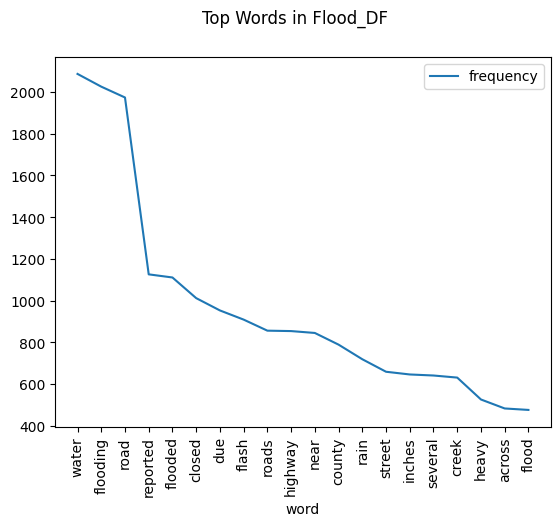

In [ ]:
# common words as a plot
# Frequency Distribution Plot
# look at first X words

# len(x) just the number of rows

x = x[0:20] # wanna play? change the 20 to 10 or 30 and see what happens...
            # you need to run the previous cell first
x.plot(x='word', y='frequency')
plt.xticks(np.arange(len(x)), x['word'], rotation=90)
plt.suptitle('Top Words in Flood_DF')
plt.show()


**Figure 5:** Top words in flood_df.

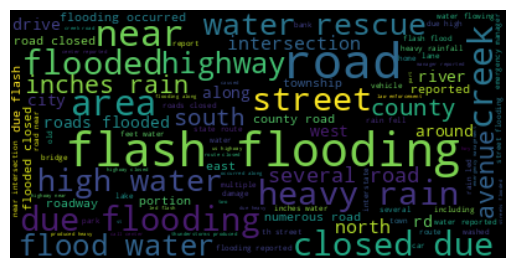

In [ ]:
# word cloud
# https://amueller.github.io/word_cloud/auto_examples/simple.html#sphx-glr-auto-examples-simple-py

from wordcloud import WordCloud

# Generate a word cloud image
wordcloud = WordCloud().generate(' '.join(flood_df['EVENT_NARRATIVE'])) # just update the column name!

# # Display the generated image:
# # the matplotlib way:
# import matplotlib.pyplot as plt
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")

# lower max_font_size
wordcloud = WordCloud(max_font_size=40).generate(' '.join(flood_df['EVENT_NARRATIVE'])) # just update the column name!
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

**Figure 6:** Top words in flood_df. Word cloud where frequent words are shown larger.

In [ ]:
# tokenizer
# make this a list with individual entries/values
flood_df['EVENT_NARRATIVE'] = flood_df.apply(lambda row: nltk.word_tokenize(row['EVENT_NARRATIVE']), axis=1)
flood_df.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,824116,TEXAS,48,2019,May,Flash Flood,Thunderstorms developed along a cold front as ...,"[thunderstorms, produced, heavy, rain, led, fl..."
23,850823,MISSOURI,29,2019,September,Flash Flood,Storms moved into southeast Kansas during the ...,"[local, roads, city, streets, multiple, lanes,..."
85,839377,OHIO,39,2019,June,Flash Flood,A stationary front supported widespread shower...,"[redhaw, creek, polk, washed, portion, route, ..."
89,839391,OHIO,39,2019,June,Flash Flood,An area of low pressure moved east along a sta...,"[localized, heavy, rain, moved, southern, mari..."
147,841501,MISSISSIPPI,28,2019,August,Flash Flood,A very moist airmass was in place across the r...,"[flash, flooding, occurred, highway, w, past, ..."


In [ ]:
# stemming
flood_df['Stemmed'] = flood_df['EVENT_NARRATIVE'].apply(lambda x: [ps.stem(y) for y in x]) # Stem every word.
flood_df.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE,Stemmed
0,824116,TEXAS,48,2019,May,Flash Flood,Thunderstorms developed along a cold front as ...,"[thunderstorms, produced, heavy, rain, led, fl...","[thunderstorm, produc, heavi, rain, led, flash..."
23,850823,MISSOURI,29,2019,September,Flash Flood,Storms moved into southeast Kansas during the ...,"[local, roads, city, streets, multiple, lanes,...","[local, road, citi, street, multipl, lane, wes..."
85,839377,OHIO,39,2019,June,Flash Flood,A stationary front supported widespread shower...,"[redhaw, creek, polk, washed, portion, route, ...","[redhaw, creek, polk, wash, portion, rout, flo..."
89,839391,OHIO,39,2019,June,Flash Flood,An area of low pressure moved east along a sta...,"[localized, heavy, rain, moved, southern, mari...","[local, heavi, rain, move, southern, marion, c..."
147,841501,MISSISSIPPI,28,2019,August,Flash Flood,A very moist airmass was in place across the r...,"[flash, flooding, occurred, highway, w, past, ...","[flash, flood, occur, highway, w, past, jupit,..."


# Making a text classification algorithm
* Put the hail_df and flood_df together as one big dataset (they have similar numbers of observations)
* Decide on how to create features for modeling (Bag of Words vs. TF-IDF)
* Split the data into test or train partitions
* Fit a classification model!
* Check out the error metrics

Try doing this with EPISODE_NARRATIVE vs. stemmed EVENT_NARRATIVE we created. We get interesting results depending on what we choose.

### Merge the Data (tmpdf)...
Just appending the hail_df rows and flood_df rows.

In [ ]:
# first, just appened the datasets you made

print(hail_df.shape)
print(flood_df.shape)

tmpdf = pd.concat([hail_df, flood_df], ignore_index=True)
print(tmpdf.shape)

(3783, 9)
(3851, 9)
(7634, 9)


In [ ]:
# check it out!
tmpdf.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,EPISODE_NARRATIVE,EVENT_NARRATIVE,Stemmed
0,848333,VERMONT,50,2019,September,Hail,A strong mid-level disturbance and cold front ...,"[quarter, size, hail, reported, okemo, ski, re...","[quarter, size, hail, report, okemo, ski, resort]"
1,844159,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"[trained, spotter, reported, hail, size, quart...","[train, spotter, report, hail, size, quarter, ..."
2,844160,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"[public, reported, via, social, media, quarter...","[public, report, via, social, media, quarter, ..."
3,844158,MONTANA,30,2019,September,Hail,Plentiful surface moisture from the southeast ...,"[public, reported, quarter, size, hail]","[public, report, quarter, size, hail]"
4,852318,CONNECTICUT,9,2019,September,Hail,A cold front pushed through southern New Engla...,"[dime, size, hail, reported, enfield]","[dime, size, hail, report, enfield]"


### Clean up the stemmed column into something useable for modeling
Let's get rid of the square brackets and leave it as a regular, cleaned up text column.

In [ ]:
# here's what it looked like before
tmpdf['Stemmed'].head()

,Stemmed
0,"[quarter, size, hail, report, okemo, ski, resort]"
1,"[train, spotter, report, hail, size, quarter, ..."
2,"[public, report, via, social, media, quarter, ..."
3,"[public, report, quarter, size, hail]"
4,"[dime, size, hail, report, enfield]"


In [ ]:
# link: https://pythonhealthcare.org/2018/12/14/101-pre-processing-data-tokenization-stemming-and-removal-of-stop-words/
# try to change
def rejoin_words(row):
    my_list = row['Stemmed']
    joined_words = ( " ".join(my_list))
    return joined_words

tmpdf['Stemmed'] = tmpdf.apply(rejoin_words, axis=1)
# here it is after - no square brackets and commas!
tmpdf['Stemmed'].head()

,Stemmed
0,quarter size hail report okemo ski resort
1,train spotter report hail size quarter along h...
2,public report via social media quarter size hail
3,public report quarter size hail
4,dime size hail report enfield


### Choose X and Y
This is where you can choose to either use 'Stemmed' or the raw 'EPISODE_NARRATIVE'. We will use 'Stemmed' as the first example - you will use the raw 'EPISODE_NARRATIVE' for your homework.

Both are 100% valid approaches to modeling - one just has a little more pre-processing.

In [ ]:
# split into X and Y
X=pd.DataFrame(tmpdf['Stemmed'])
y=tmpdf['EVENT_TYPE']
print(X.shape,y.shape)

(7634, 1) (7634,)


In [ ]:
X.head()

,Stemmed
0,quarter size hail report okemo ski resort
1,train spotter report hail size quarter along h...
2,public report via social media quarter size hail
3,public report quarter size hail
4,dime size hail report enfield


In [ ]:
# BTW - if you haven't already, you can mount your drive
# and save a copy of this data if you want

# 🔵 Bag of Words
This will tell you how many times each word was mentioned in a sample.

**Check out the documentation:** [sklearn count vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)

[Unigram, bigram, trigram](https://www.google.com/url?sa=i&url=https%3A%2F%2Farshadmehmood.com%2Fdevelopment%2Fgenerate-unigrams-bigrams-trigrams-ngrams-etc-in-python%2F&psig=AOvVaw2DPfI9oyB65ONqb7AEDzM6&ust=1592425067747000&source=images&cd=vfe&ved=0CAIQjRxqFwoTCJChmOeTh-oCFQAAAAAdAAAAABAD) is something you should be comfortable with.


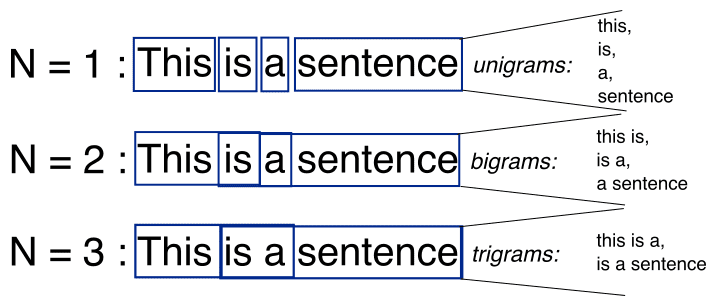

**Figure 7:** Examples of how to create unigrams, bigrams and trigrams (bag of words.)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

# ---------------------------------------
# 1. Start from raw text + labels
# ---------------------------------------
X_text = X['Stemmed']   # your stemmed text column
y_vec  = y              # your target vector

# ---------------------------------------
# 2. Split TEXT first: 60% train, 40% temp
# ---------------------------------------
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
                                                      X_text,
                                                      y_vec,
                                                      test_size=0.4,      # leaves 60% for train
                                                      random_state=42
)

# ---------------------------------------
# 3. Split temp into 20% val, 20% test
# ---------------------------------------
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,      # half of the 40% → 20/20
    random_state=42
)

print("Train:", len(X_train_text), "Val:", len(X_val_text), "Test:", len(X_test_text))

# ---------------------------------------
# 4. Build CountVectorizer and FIT ONLY ON TRAIN
# ---------------------------------------
token = RegexpTokenizer(r'[a-zA-Z0-9]+')

cv = CountVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 1),          # (1,2) is unigrams + bigrams
    tokenizer=token.tokenize
)

X_train_counts = cv.fit_transform(X_train_text)   # fit on TRAIN only
X_val_counts   = cv.transform(X_val_text)         # transform val
X_test_counts  = cv.transform(X_test_text)        # transform test

print("Train matrix:", X_train_counts.shape)
print("Val matrix:  ", X_val_counts.shape)
print("Test matrix: ", X_test_counts.shape)

Train: 4580 Val: 1527 Test: 1527
Train matrix: (4580, 4961)
Val matrix:   (1527, 4961)
Test matrix:  (1527, 4961)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
X_train_counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 47677 stored elements and shape (4580, 4961)>

In [ ]:
dense_text_counts = X_train_counts.toarray()
print(dense_text_counts[0])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
print(np.sum(dense_text_counts[0]))

100


In [ ]:
from sklearn.tree import DecisionTreeClassifier
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# Model Generation Using Multinomial Naive Bayes
clf = DecisionTreeClassifier(min_samples_leaf=5).fit(X_train_counts, y_train)
predicted= clf.predict(X_test_counts)
print("DTC Accuracy:",metrics.accuracy_score(y_test, predicted))

# WOW! 99% accuracy on test data.

# think of how much time this saves and we didn't even have
# to read any of this, just needed to be careful with our
# data prep and let it rip!

DTC Accuracy: 0.9947609692206941


In [ ]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

 Flash Flood       0.99      0.99      0.99       783
        Hail       0.99      0.99      0.99       744

    accuracy                           0.99      1527
   macro avg       0.99      0.99      0.99      1527
weighted avg       0.99      0.99      0.99      1527



In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predicted) # only a handful of misses here, wow...

array([[779,   4],
       [  4, 740]])

## xAI
Using just 100 rows to make it run fast... use more in production

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# 1. Make X_test dense just for permutation importance
X_test_dense = X_test_counts.toarray()   # (1527, 4961) → manageable in memory

# 2. Run permutation importance
result = permutation_importance(
    clf,
    X_test_dense[0:100],      # now a plain NumPy array
    y_test[0:100],
    n_repeats=1, # should be more but that's OK....
    random_state=42
)

# 3. Map importances back to words
feature_names = np.array(cv.get_feature_names_out())
importances = result.importances_mean

top_idx = importances.argsort()[::-1][:10]

top10 = pd.DataFrame({
    "word": feature_names[top_idx],
    "importance": importances[top_idx]
})

print(top10.to_string(index=False))


       word  importance
       hail        0.27
      water        0.04
      creek        0.01
      river        0.01
      flood        0.01
       wash        0.01
  frankford        0.00
  frankfort        0.00
   franklin        0.00
franklinton        0.00


# 🔵 TF-IDF
This is a more sophisticated method. TF-IDF is a numerical statistic that is intended to reflect how important a word is to a document in a collection or corpus.

The TF-IDF score is calculated by multiplying the term frequency (TF) by the inverse document frequency (IDF). For example, if a word appears 3 times in a 100-word document, its TF is $0.03$. If this word appears in 1,000 out of 10 million documents, its IDF is $\log (\frac{10,000,000}{1,000})=4$. The final TF-IDF score is the product of these two values, which is $0.03\times 4=0.12$.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import RegexpTokenizer

# ---------------------------------------
# 1. Start from raw text + labels
# ---------------------------------------
X_text = X['Stemmed']   # your stemmed text column
y_vec  = y              # your target vector

# ---------------------------------------
# 2. Split TEXT first: 60% train, 40% temp
# ---------------------------------------
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text,
    y_vec,
    test_size=0.4,      # leaves 60% for train
    random_state=42
    # stratify=y_vec   # optional if you want balanced splits
)

# ---------------------------------------
# 3. Split temp into 20% val, 20% test
# ---------------------------------------
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,      # half of the 40% → 20/20
    random_state=42
    # stratify=y_temp  # same note as above
)

print("Train:", len(X_train_text), "Val:", len(X_val_text), "Test:", len(X_test_text))

# ---------------------------------------
# 4. Build TF-IDF vectorizer and FIT ONLY ON TRAIN
# ---------------------------------------
token = RegexpTokenizer(r'[a-zA-Z0-9]+')

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 1),          # (1,2) if you want unigrams + bigrams
    tokenizer=token.tokenize
)

X_train_tf = tfidf.fit_transform(X_train_text)   # fit on TRAIN only
X_val_tf   = tfidf.transform(X_val_text)         # transform val
X_test_tf  = tfidf.transform(X_test_text)        # transform test

print("Train TF-IDF matrix:", X_train_tf.shape)
print("Val TF-IDF matrix:  ", X_val_tf.shape)
print("Test TF-IDF matrix: ", X_test_tf.shape)

Train: 4580 Val: 1527 Test: 1527


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Train TF-IDF matrix: (4580, 4961)
Val TF-IDF matrix:   (1527, 4961)
Test TF-IDF matrix:  (1527, 4961)


In [ ]:
X_train_tf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 47677 stored elements and shape (4580, 4961)>

In [ ]:
dense_text_counts = X_train_tf.toarray()
print(dense_text_counts[0])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.07682606 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.07421723 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.18836521 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.09589362 0.
 0.         0.         0.         0.         0.         

In [ ]:
# fit a model
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
# Model Generation Using Multinomial Naive Bayes
clf = DecisionTreeClassifier(min_samples_leaf=5).fit(X_train_tf, y_train)
predicted= clf.predict(X_test_tf)
print("DTC Accuracy:",metrics.accuracy_score(y_test, predicted))

# 98%!

DTC Accuracy: 0.9816633922724296


# xAI
Simplified... be sure to up the rows and repeats...

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# 1. Make X_test dense just for permutation importance
X_test_tf = X_test_tf.toarray()   # (1527, 4961) → manageable in memory

# 2. Run permutation importance
result = permutation_importance(
    clf,
    X_test_tf[0:100],      # now a plain NumPy array
    y_test[0:100],
    n_repeats=1, # should be more but that's OK....
    random_state=42
)

# 3. Map importances back to words
feature_names = np.array(cv.get_feature_names_out())
importances = result.importances_mean

top_idx = importances.argsort()[::-1][:10]

top10 = pd.DataFrame({
    "word": feature_names[top_idx],
    "importance": importances[top_idx]
})

print(top10.to_string(index=False))


  word  importance
  hail        0.24
  size        0.14
 water        0.05
report        0.02
pictur        0.01
 relay        0.01
  wash        0.01
  wind        0.01
 flood        0.01
 damag        0.01


Seeing words that might introduce some data leakage might have you consider adding words to the stoplist! `0` is Flood, `1` is Hail (it goes alphabetically).